# import

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

# Dataset loading


In [3]:
dataset = pd.read_csv("/content/Depression Data.csv")
dataset.shape
dataset.head()

,1. Age,2. Gender,5. Academic Year,6. Current CGPA,7. Did you receive a waiver or scholarship at your university?,"1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?","2. In a semester, how often have you been unable to stop worrying about your academic affairs?","3. In a semester, how often have you had trouble relaxing due to academic pressure?","4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?","5. In a semester, how often have you worried too much about academic affairs?",...,"2. In a semester, how often have you been feeling down, depressed or hopeless?","3. In a semester, how often have you had trouble falling or staying asleep, or sleeping too much?","4. In a semester, how often have you been feeling tired or having little energy?","5. In a semester, how often have you had poor appetite or overeating?","6. In a semester, how often have you been feeling bad about yourself - or that you are a failure or have let yourself or your family down?","7. In a semester, how often have you been having trouble concentrating on things, such as reading the books or watching television?","8. In a semester, how often have you moved or spoke too slowly for other people to notice? Or you've been moving a lot more than usual because you've been restless?","9. In a semester, how often have you had thoughts that you would be better off dead, or of hurting yourself?",Depression Value,Depression Label
0,18-22,Female,Fourth Year or Equivalent,2.50 - 2.99,No,1,1,1,2,2,...,2,1,1,2,1,1,1,1,11,Moderate Depression
1,18-22,Male,First Year or Equivalent,3.80 - 4.00,No,2,2,1,1,1,...,1,1,1,1,1,1,1,1,9,Mild Depression
2,18-22,Male,First Year or Equivalent,3.00 - 3.39,No,2,1,1,0,2,...,0,2,3,2,2,2,2,1,16,Moderately Severe Depression
3,18-22,Male,First Year or Equivalent,3.40 - 3.79,No,2,1,1,1,1,...,1,1,1,1,1,1,1,1,9,Mild Depression
4,18-22,Male,First Year or Equivalent,3.40 - 3.79,No,1,1,1,1,1,...,1,1,1,1,1,1,1,1,9,Mild Depression


In [4]:
print(dataset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1977 entries, 0 to 1976
Data columns (total 37 columns):
 #   Column                                                                                                                                                                 Non-Null Count  Dtype 
---  ------                                                                                                                                                                 --------------  ----- 
 0   1. Age                                                                                                                                                                 1977 non-null   object
 1   2. Gender                                                                                                                                                              1971 non-null   object
 2   5. Academic Year                                                                                            

In [5]:
dataset["Depression Label"].value_counts()

,count
Depression Label,
Moderately Severe Depression,495
Severe Depression,488
Moderate Depression,449
Mild Depression,408
Minimal Depression,93
No Depression,44


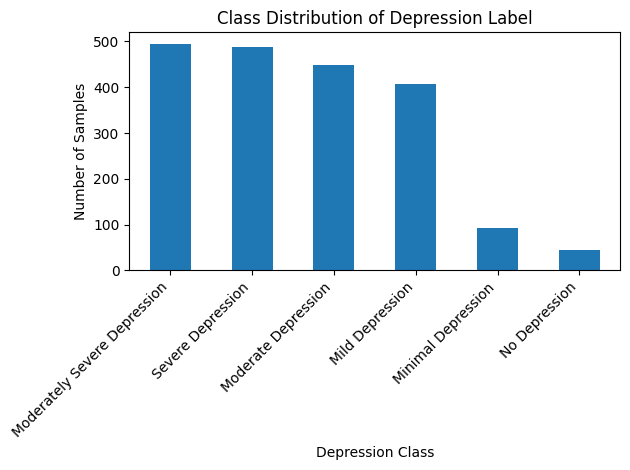

In [6]:
dataset["Depression Label"].value_counts().plot(kind="bar")
plt.title("Class Distribution of Depression Label")
plt.xlabel("Depression Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [7]:
dataset

,1. Age,2. Gender,5. Academic Year,6. Current CGPA,7. Did you receive a waiver or scholarship at your university?,"1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?","2. In a semester, how often have you been unable to stop worrying about your academic affairs?","3. In a semester, how often have you had trouble relaxing due to academic pressure?","4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?","5. In a semester, how often have you worried too much about academic affairs?",...,"2. In a semester, how often have you been feeling down, depressed or hopeless?","3. In a semester, how often have you had trouble falling or staying asleep, or sleeping too much?","4. In a semester, how often have you been feeling tired or having little energy?","5. In a semester, how often have you had poor appetite or overeating?","6. In a semester, how often have you been feeling bad about yourself - or that you are a failure or have let yourself or your family down?","7. In a semester, how often have you been having trouble concentrating on things, such as reading the books or watching television?","8. In a semester, how often have you moved or spoke too slowly for other people to notice? Or you've been moving a lot more than usual because you've been restless?","9. In a semester, how often have you had thoughts that you would be better off dead, or of hurting yourself?",Depression Value,Depression Label
0,18-22,Female,Fourth Year or Equivalent,2.50 - 2.99,No,1,1,1,2,2,...,2,1,1,2,1,1,1,1,11,Moderate Depression
1,18-22,Male,First Year or Equivalent,3.80 - 4.00,No,2,2,1,1,1,...,1,1,1,1,1,1,1,1,9,Mild Depression
2,18-22,Male,First Year or Equivalent,3.00 - 3.39,No,2,1,1,0,2,...,0,2,3,2,2,2,2,1,16,Moderately Severe Depression
3,18-22,Male,First Year or Equivalent,3.40 - 3.79,No,2,1,1,1,1,...,1,1,1,1,1,1,1,1,9,Mild Depression
4,18-22,Male,First Year or Equivalent,3.40 - 3.79,No,1,1,1,1,1,...,1,1,1,1,1,1,1,1,9,Mild Depression
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1972,23-26,Male,Fourth Year or Equivalent,3.40 - 3.79,No,1,2,2,2,2,...,2,1,2,2,1,1,1,1,13,Moderate Depression
1973,23-26,Female,Fourth Year or Equivalent,3.40 - 3.79,No,2,2,2,1,1,...,2,1,2,1,0,1,1,0,9,Mild Depression
1974,23-26,Female,Other,3.80 - 4.00,No,1,0,1,1,3,...,3,3,3,3,3,3,1,0,22,Severe Depression
1975,23-26,Male,Fourth Year or Equivalent,3.00 - 3.39,No,1,1,1,2,1,...,1,1,2,2,1,2,2,0,11,Moderate Depression


## EDA

In [8]:
numerical_features = dataset.select_dtypes(include=['int64', 'float64'])
categorical_features = dataset.select_dtypes(include=['object'])

print("Numerical Features:", numerical_features.shape[1])
print("Categorical Features:", categorical_features.shape[1])

Numerical Features: 29
Categorical Features: 8


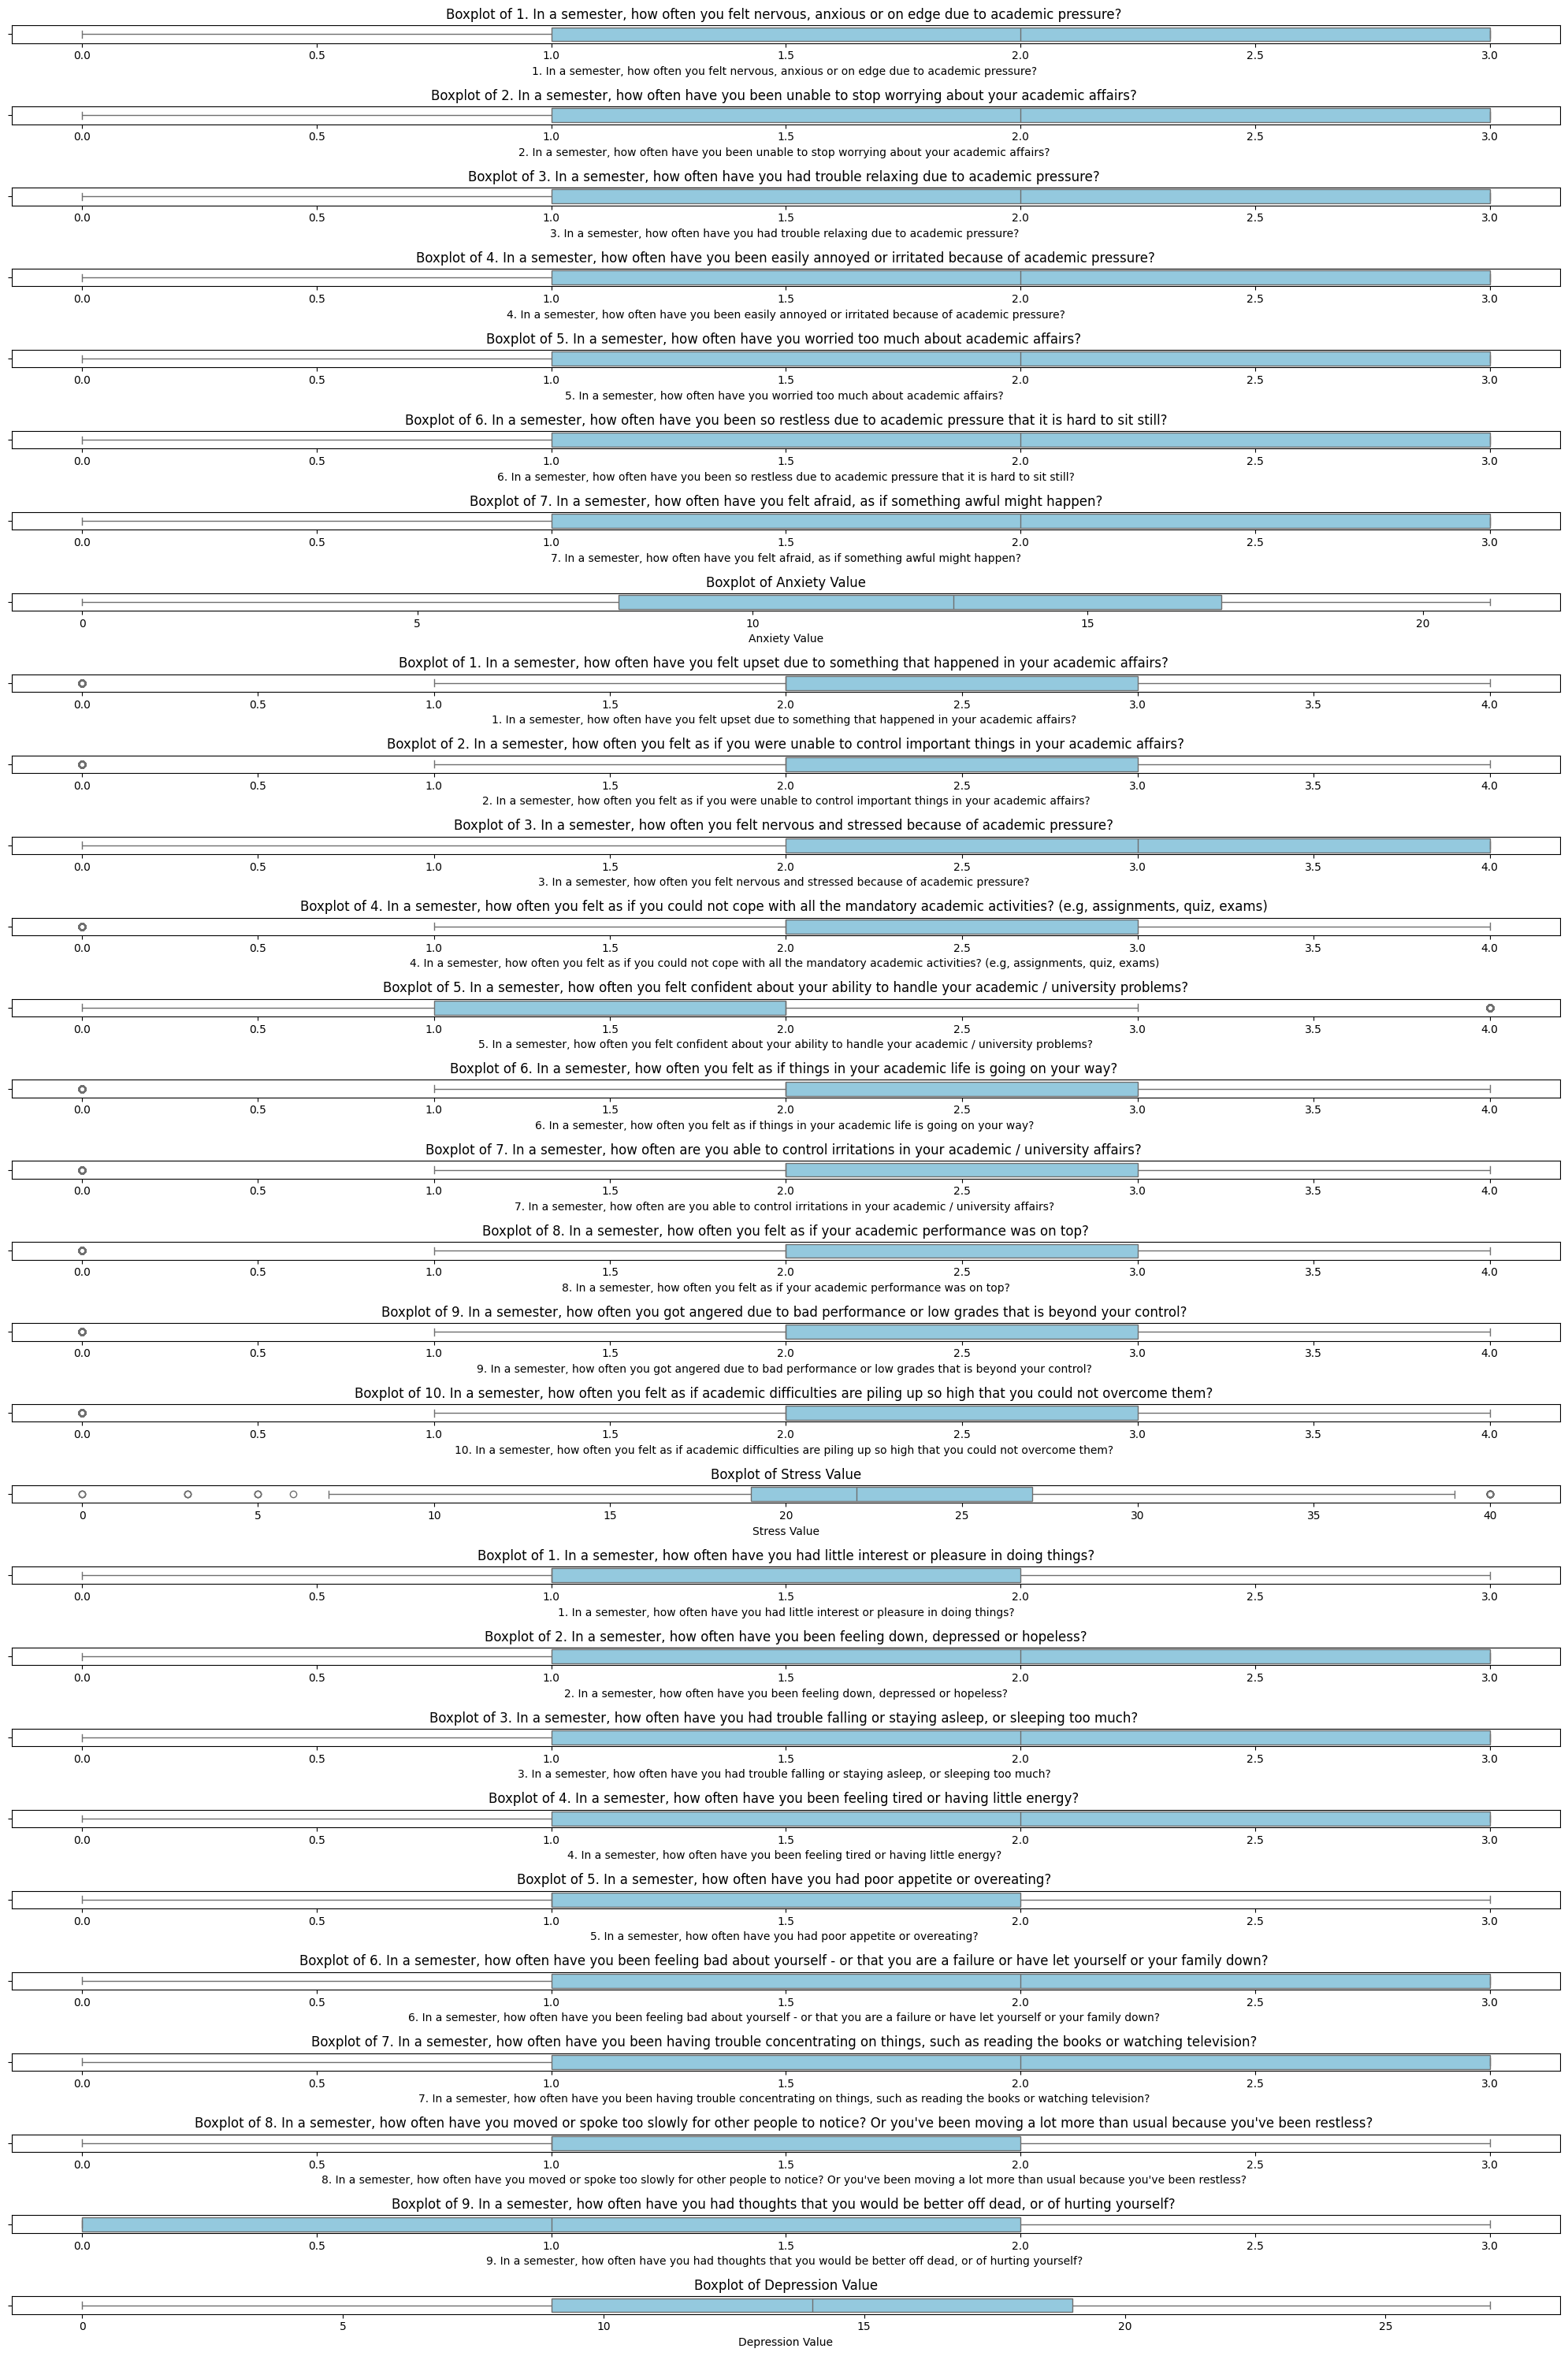

In [9]:
numeric_cols = dataset.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(20, 30))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i)
    sns.boxplot(x=dataset[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.tight_layout()

plt.show()

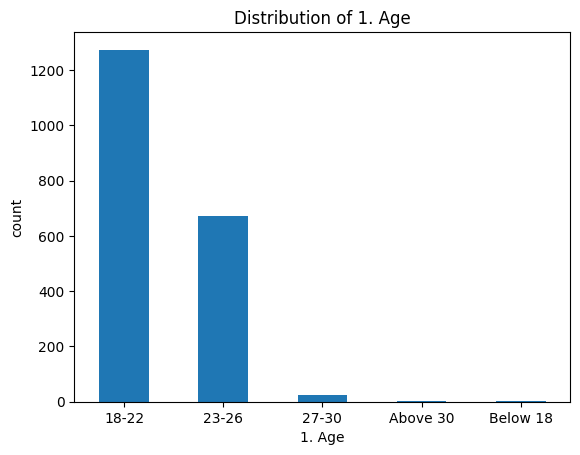

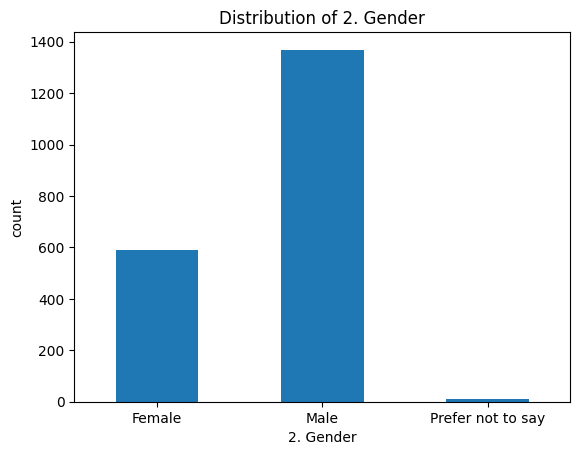

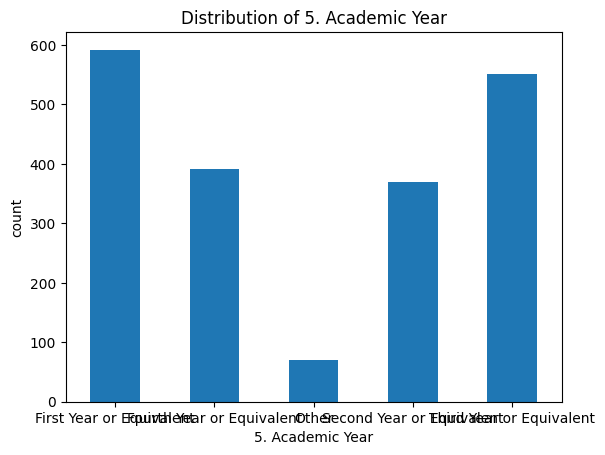

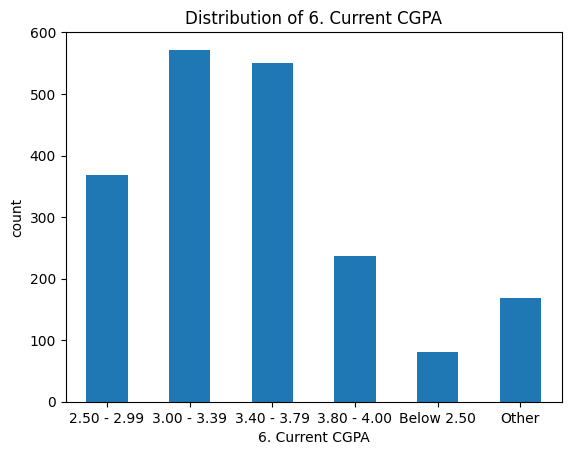

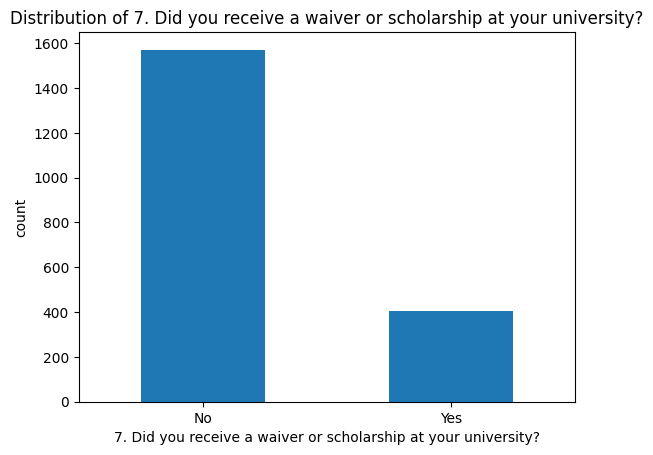

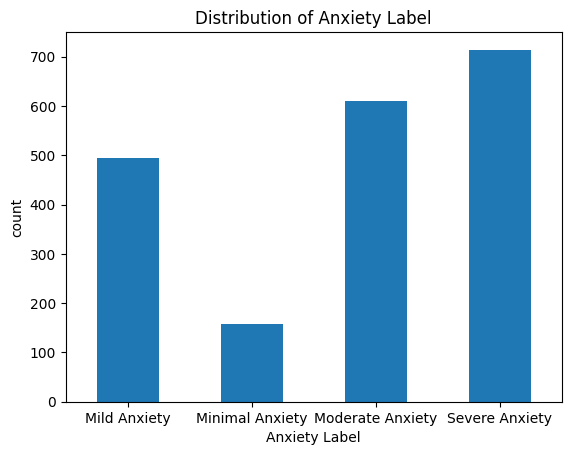

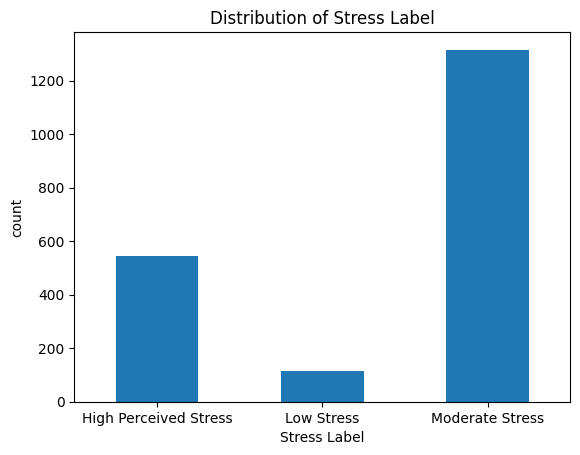

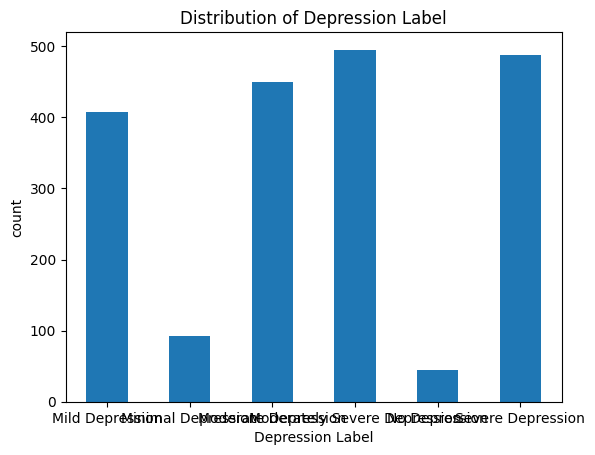

In [10]:
for col in categorical_features:
    plt.title(f'Distribution of {col}')
    categorical_features[col].value_counts().sort_index().plot(kind='bar', rot=0, xlabel=col,ylabel='count')
    plt.show()

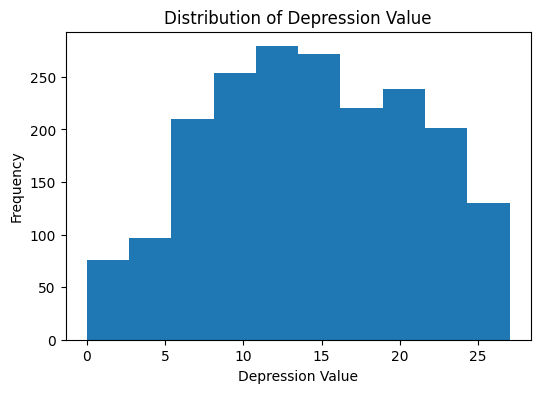

In [11]:
plt.figure(figsize=(6,4))
plt.hist(dataset["Depression Value"], bins=10)
plt.title("Distribution of Depression Value")
plt.xlabel("Depression Value")
plt.ylabel("Frequency")
plt.show()

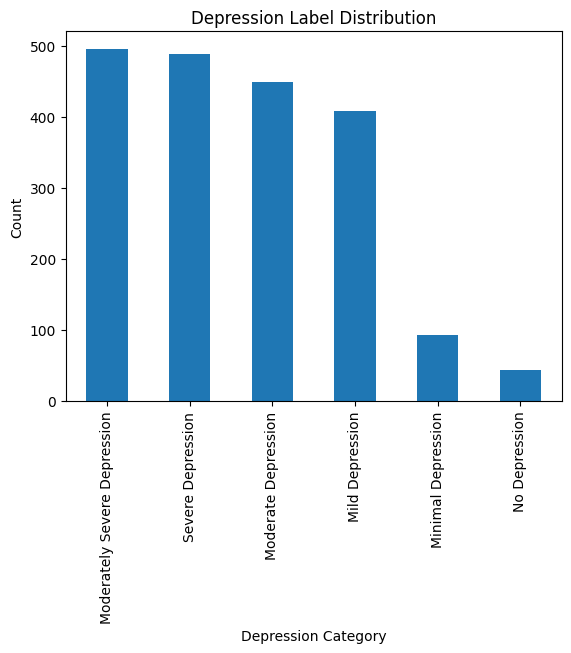

In [12]:
dataset["Depression Label"].value_counts().plot(kind='bar')
plt.title("Depression Label Distribution")
plt.xlabel("Depression Category")
plt.ylabel("Count")
plt.show()

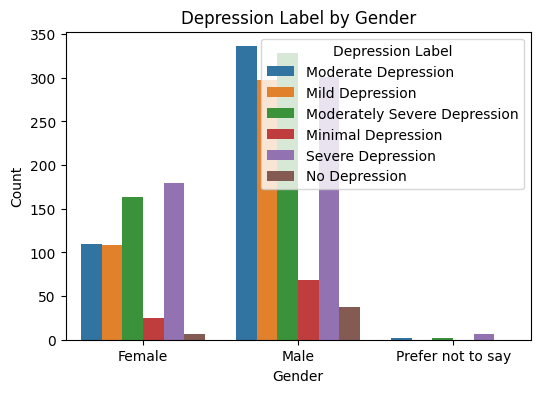

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x="2. Gender", hue="Depression Label", data=dataset)
plt.title("Depression Label by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

In [14]:
# Calculate the correlation matrix
correlation_matrix = numerical_features.corr()
correlation_matrix

,"1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?","2. In a semester, how often have you been unable to stop worrying about your academic affairs?","3. In a semester, how often have you had trouble relaxing due to academic pressure?","4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?","5. In a semester, how often have you worried too much about academic affairs?","6. In a semester, how often have you been so restless due to academic pressure that it is hard to sit still?","7. In a semester, how often have you felt afraid, as if something awful might happen?",Anxiety Value,"1. In a semester, how often have you felt upset due to something that happened in your academic affairs?","2. In a semester, how often you felt as if you were unable to control important things in your academic affairs?",...,"1. In a semester, how often have you had little interest or pleasure in doing things?","2. In a semester, how often have you been feeling down, depressed or hopeless?","3. In a semester, how often have you had trouble falling or staying asleep, or sleeping too much?","4. In a semester, how often have you been feeling tired or having little energy?","5. In a semester, how often have you had poor appetite or overeating?","6. In a semester, how often have you been feeling bad about yourself - or that you are a failure or have let yourself or your family down?","7. In a semester, how often have you been having trouble concentrating on things, such as reading the books or watching television?","8. In a semester, how often have you moved or spoke too slowly for other people to notice? Or you've been moving a lot more than usual because you've been restless?","9. In a semester, how often have you had thoughts that you would be better off dead, or of hurting yourself?",Depression Value
"1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?",1.000000,0.495772,0.511390,0.635193,0.643153,0.580194,0.598137,0.805124,0.491888,0.511299,...,0.178723,0.592705,0.440335,0.500472,0.415241,0.555560,0.483629,0.428253,0.416095,0.627624
"2. In a semester, how often have you been unable to stop worrying about your academic affairs?",0.495772,1.000000,0.473536,0.481888,0.498965,0.441217,0.447900,0.698547,0.342687,0.356513,...,0.187395,0.426127,0.363543,0.393809,0.361505,0.417127,0.388554,0.324906,0.289480,0.492171
"3. In a semester, how often have you had trouble relaxing due to academic pressure?",0.511390,0.473536,1.000000,0.564550,0.517929,0.519029,0.499364,0.740075,0.377510,0.400276,...,0.205356,0.494548,0.438430,0.474976,0.372413,0.444108,0.436933,0.371762,0.318506,0.554905
"4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?",0.635193,0.481888,0.564550,1.000000,0.695984,0.583702,0.605070,0.824525,0.459347,0.492151,...,0.204851,0.588961,0.443092,0.508928,0.423595,0.563925,0.503970,0.447433,0.422247,0.642284
"5. In a semester, how often have you worried too much about academic affairs?",0.643153,0.498965,0.517929,0.695984,1.000000,0.660851,0.662909,0.846620,0.435808,0.459529,...,0.190281,0.616251,0.452073,0.515111,0.425131,0.576295,0.513104,0.434942,0.389694,0.642935
"6. In a semester, how often have you been so restless due to academic pressure that it is hard to sit still?",0.580194,0.441217,0.519029,0.583702,0.660851,1.000000,0.620680,0.797915,0.396751,0.422960,...,0.189561,0.559738,0.442977,0.533634,0.412510,0.500339,0.451295,0.438958,0.387305,0.611745
"7. In a semester, how often have you felt afraid, as if something awful might happen?",0.598137,0.447900,0.499364,0.605070,0.662909,0.620680,1.000000,0.807292,0.452806,0.459616,...,0.209400,0.625255,0.482671,0.509573,0.431500,0.583713,0.493026,0.476058,0.446520,0.666259
Anxiety Value,0.805124,0.698547,0.740075,0.824525,0.846620,0.797915,0.807292,1.000000,0.535160,0.561286,...,0.247788,0.707107,0.555328,0.622422,0.515040,0.659581,0

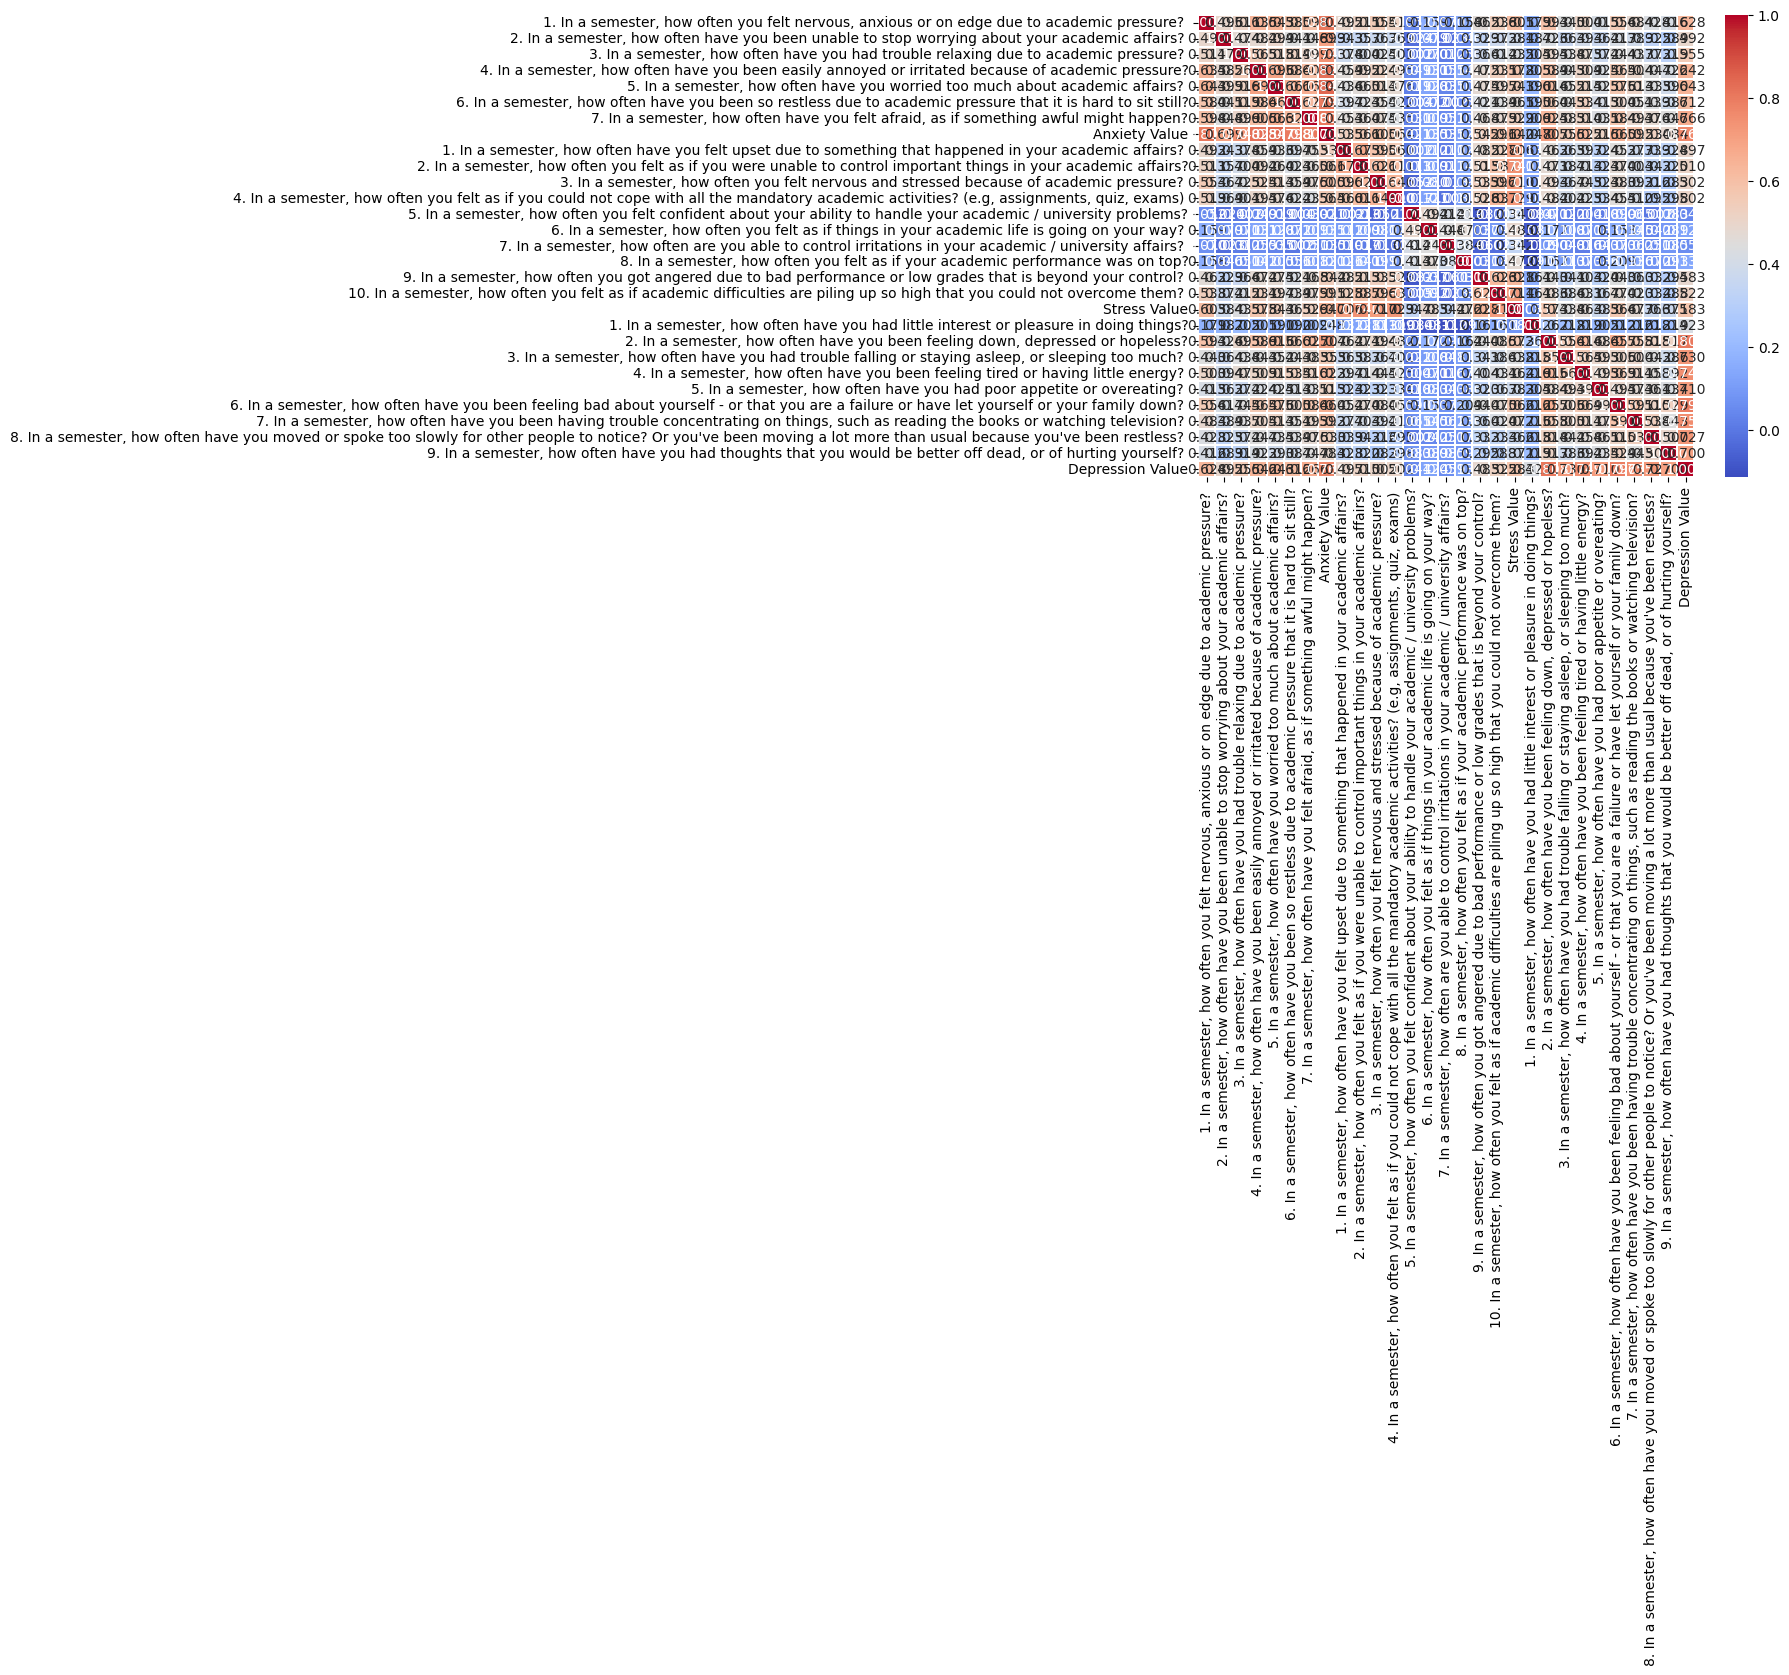

In [15]:
# Plotting the heatmap for correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.3)
plt.show()

/tmp/ipython-input-2256668804.py:17: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


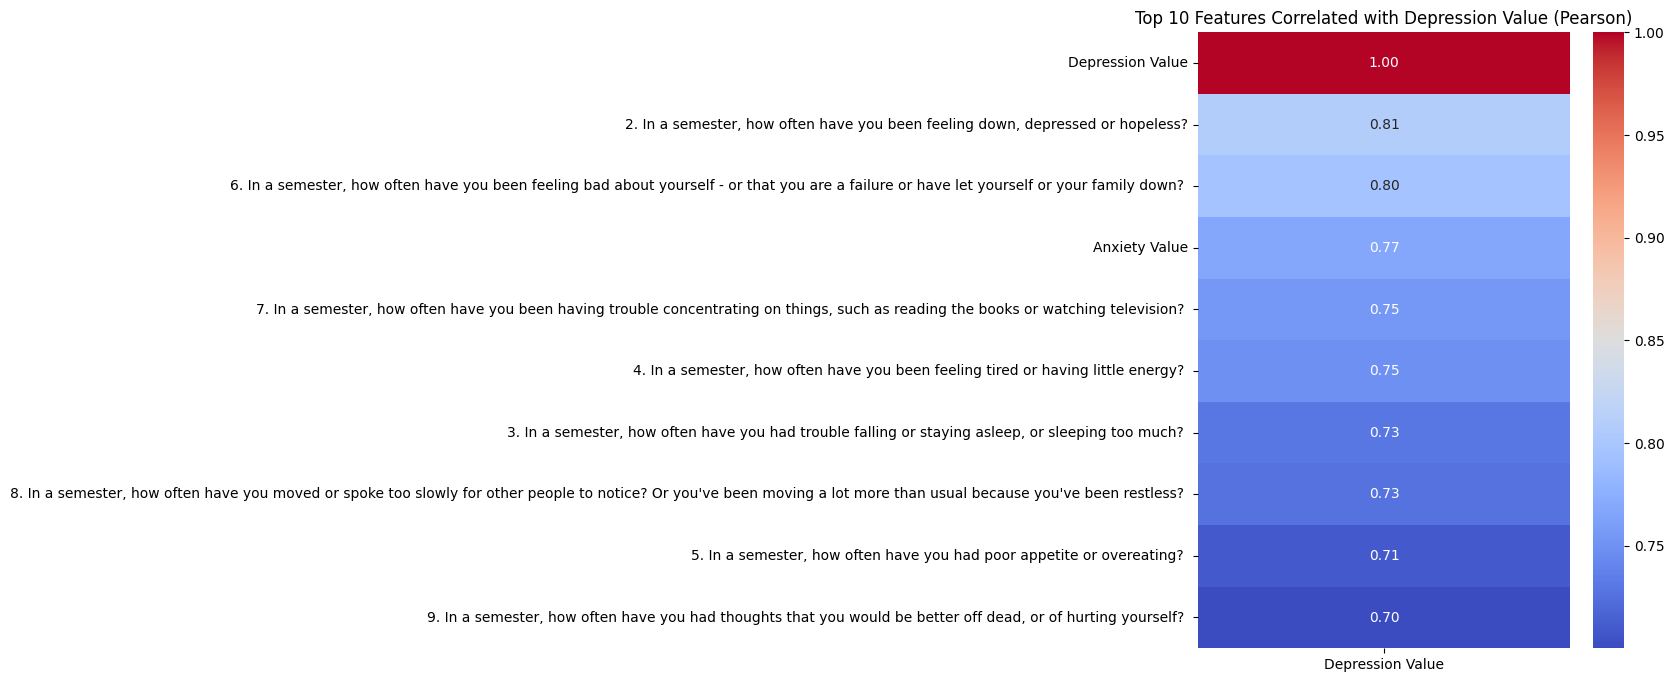

In [16]:
target_num = "Depression Value"

corr_pearson = numerical_features.corr(method="pearson")[[target_num]].sort_values(
    by=target_num, ascending=False
)

top10 = corr_pearson.head(10)
plt.figure(figsize=(6,8))
sns.heatmap(
    top10,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    cbar=True
)
plt.title("Top 10 Features Correlated with Depression Value (Pearson)")
plt.tight_layout()
plt.show()


/tmp/ipython-input-4024324920.py:30: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


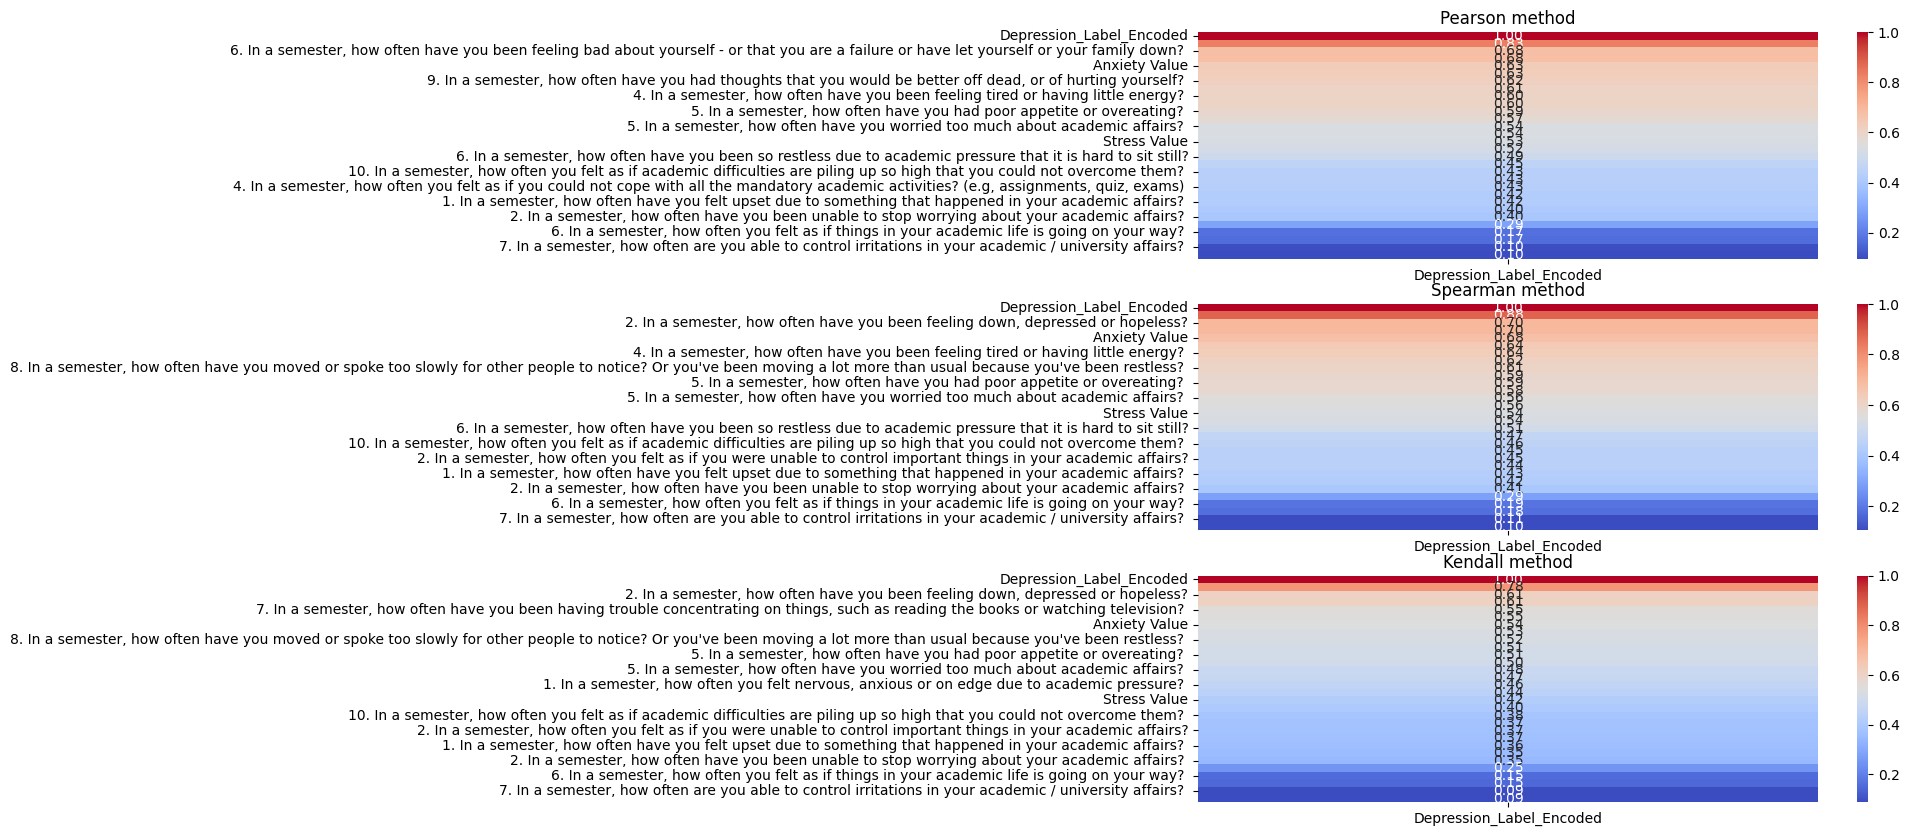

In [17]:
numerical_data = dataset.select_dtypes(include=np.number)

le = LabelEncoder()
target_encoded = le.fit_transform(dataset["Depression Label"])

numerical_with_target = numerical_data.copy()
numerical_with_target["Depression_Label_Encoded"] = target_encoded

fig, ax = plt.subplots(3, 1, figsize=(10, 10))

corr1 = numerical_with_target.corr(method="pearson")[["Depression_Label_Encoded"]].sort_values(
    by="Depression_Label_Encoded", ascending=False
)
corr2 = numerical_with_target.corr(method="spearman")[["Depression_Label_Encoded"]].sort_values(
    by="Depression_Label_Encoded", ascending=False
)
corr3 = numerical_with_target.corr(method="kendall")[["Depression_Label_Encoded"]].sort_values(
    by="Depression_Label_Encoded", ascending=False
)


ax[0].set_title("Pearson method")
ax[1].set_title("Spearman method")
ax[2].set_title("Kendall method")

sns.heatmap(corr1, ax=ax[0], annot=True, cmap="coolwarm", fmt=".2f")
sns.heatmap(corr2, ax=ax[1], annot=True, cmap="coolwarm", fmt=".2f")
sns.heatmap(corr3, ax=ax[2], annot=True, cmap="coolwarm", fmt=".2f")

plt.tight_layout()
plt.show()

In [18]:
# Check imbalance in data
class_counts = dataset.groupby("Depression Label").size()

columns = ["Depression Label", "Count", "Percentage"]
labels = class_counts.index.tolist()
count = []
percentage = []

total_samples = len(dataset)

for label in labels:
    c = class_counts[label]
    count.append(c)
    percent = (c / total_samples) * 100
    percentage.append(percent)


imbalance_df = pd.DataFrame(
    list(zip(labels, count, percentage)),
    columns=columns
)

imbalance_df

,Depression Label,Count,Percentage
0,Mild Depression,408,20.637329
1,Minimal Depression,93,4.704097
2,Moderate Depression,449,22.711179
3,Moderately Severe Depression,495,25.037936
4,No Depression,44,2.225594
5,Severe Depression,488,24.683864


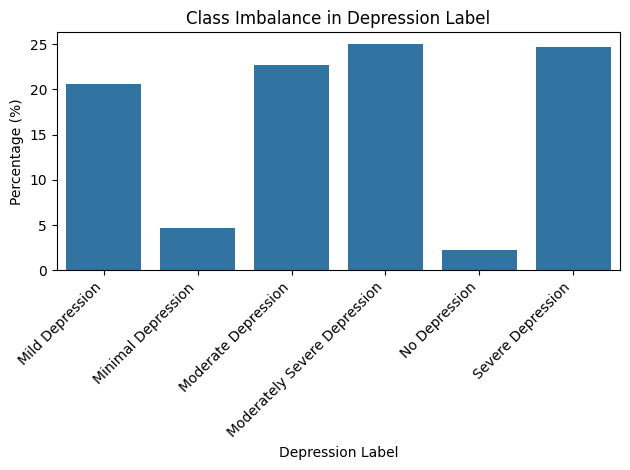

In [19]:
sns.barplot(data=imbalance_df,  x=imbalance_df["Depression Label"],y=imbalance_df["Percentage"])

plt.title("Class Imbalance in Depression Label")
plt.xlabel("Depression Label")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

/tmp/ipython-input-1765111530.py:11: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


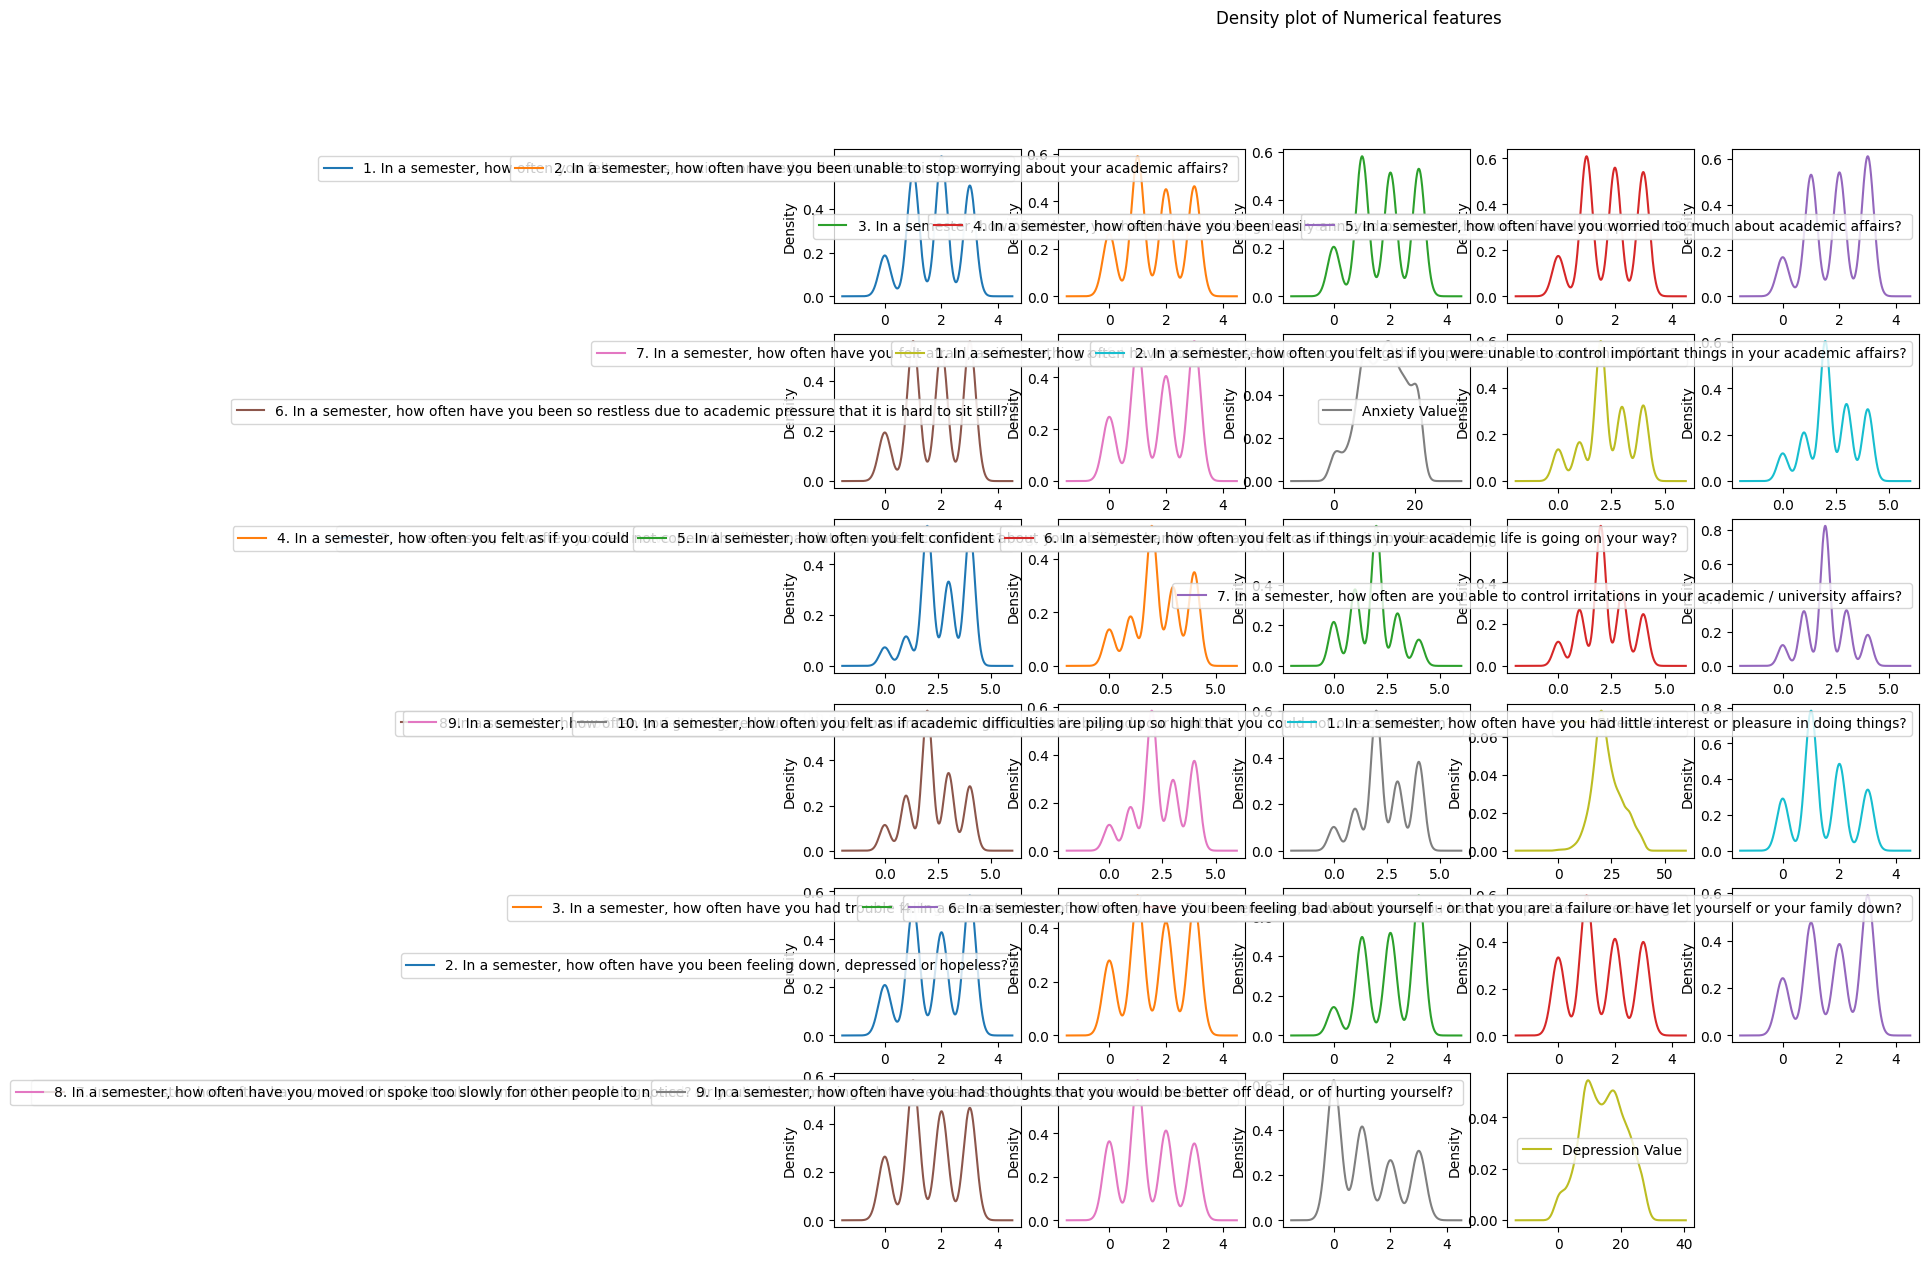

In [20]:
#Density plots of numerical features
numerical_data = dataset.select_dtypes(include="number")
numerical_data.plot(
    kind="density",
    figsize=(14,14),
    subplots=True,
    layout=(6,5),   # 6×5 = 30 slots (enough for your numeric features)
    title="Density plot of Numerical features",
    sharex=False
)
plt.tight_layout()
plt.show()

#  DATASET PRE-PROCESSING


In [21]:
dataset_raw = dataset.copy()

In [22]:
print("Dataset shape:", dataset.shape)
dataset.isnull().sum()

Dataset shape: (1977, 37)


,0
1. Age,0
2. Gender,6
5. Academic Year,0
6. Current CGPA,0
7. Did you receive a waiver or scholarship at your university?,0
"1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?",0
"2. In a semester, how often have you been unable to stop worrying about your academic affairs?",0
"3. In a semester, how often have you had trouble relaxing due to academic pressure?",0
"4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?",0
"5. In a semester, how often have you worried too much about academic affairs?",0


In [23]:
missing_counts = dataset.isnull().sum()
missing_counts[missing_counts > 0]

,0
2. Gender,6


In [24]:
#categorical = mode
#numerical = median
cat_cols = dataset.select_dtypes(include=["object"]).columns

for col in cat_cols:
    dataset[col] = dataset[col].fillna(dataset[col].mode()[0])

num_cols = dataset.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    dataset[col] = dataset[col].fillna(dataset[col].median())

In [25]:
dataset.isnull().sum().sum()

np.int64(0)

In [26]:
#categorical columns exist
dataset.select_dtypes(include=["object"]).columns

Index(['1. Age', '2. Gender', '5. Academic Year', '6. Current CGPA',
       '7. Did you receive a waiver or scholarship at your university?',
       'Anxiety Label', 'Stress Label', 'Depression Label'],
      dtype='object')

In [27]:
target = "Depression Label"
y = dataset[target]              # keeping labels as they are
X = dataset.drop(columns=[target])

In [28]:
#one-hot encoding
X_encoded = pd.get_dummies(X, drop_first=True)

In [29]:
print("Before encoding:", X.shape)
print("After encoding:", X_encoded.shape)

Before encoding: (1977, 36)
After encoding: (1977, 50)


In [30]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)
X_scaled.mean(), X_scaled.std()

(np.float64(-1.5526275257883827e-17), np.float64(1.0))

In [31]:
y.value_counts() #to check how many classes

,count
Depression Label,
Moderately Severe Depression,495
Severe Depression,488
Moderate Depression,449
Mild Depression,408
Minimal Depression,93
No Depression,44


# Dataset Splitting

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,        # 20% test, 80% train
    random_state=42,      # reproducibility
    stratify=y            # preserve class distribution
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1581, 50)
X_test shape: (396, 50)
y_train shape: (1581,)
y_test shape: (396,)


In [33]:
print("Original distribution:")
print(y.value_counts(normalize=True))

print("\nTrain distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True))

Original distribution:
Depression Label
Moderately Severe Depression    0.250379
Severe Depression               0.246839
Moderate Depression             0.227112
Mild Depression                 0.206373
Minimal Depression              0.047041
No Depression                   0.022256
Name: proportion, dtype: float64

Train distribution:
Depression Label
Moderately Severe Depression    0.250474
Severe Depression               0.246679
Moderate Depression             0.227071
Mild Depression                 0.206199
Minimal Depression              0.047438
No Depression                   0.022138
Name: proportion, dtype: float64

Test distribution:
Depression Label
Moderately Severe Depression    0.250000
Severe Depression               0.247475
Moderate Depression             0.227273
Mild Depression                 0.207071
Minimal Depression              0.045455
No Depression                   0.022727
Name: proportion, dtype: float64


## Model Training


 kmeans

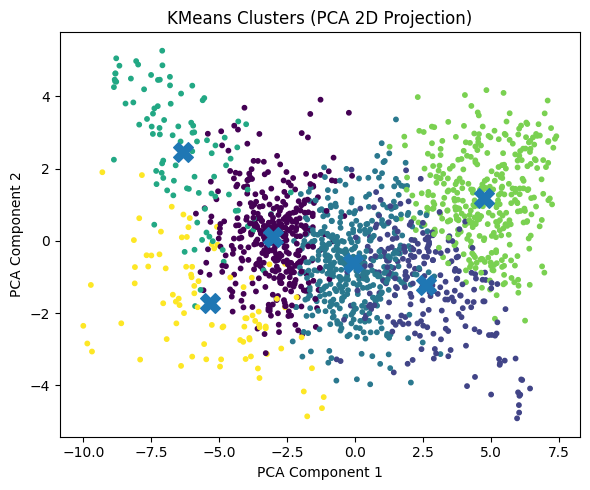

In [34]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

k = y.nunique()  # 6 clusters (same as number of depression classes)

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_train)  # you can also use full X_scaled

# PCA for 2D plot
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_train)

centroids_2d = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(6,5))
plt.scatter(X_2d[:,0], X_2d[:,1], c=cluster_labels, s=10)
plt.scatter(centroids_2d[:,0], centroids_2d[:,1], s=200, marker="X")
plt.title("KMeans Clusters (PCA 2D Projection)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.tight_layout()
plt.show()

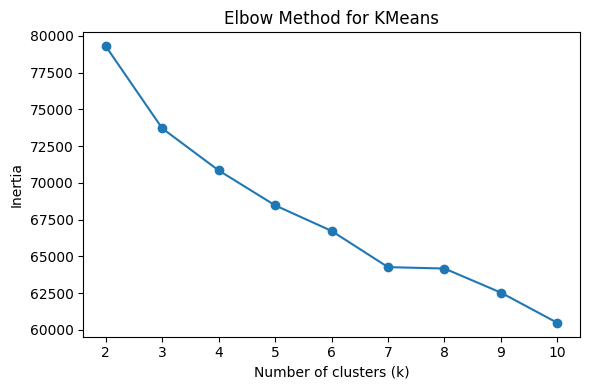

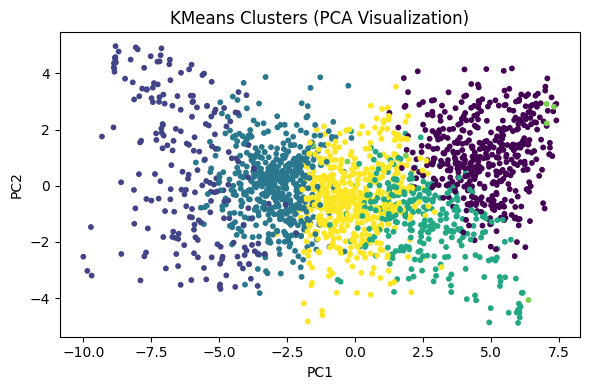

Depression Label,Mild Depression,Minimal Depression,Moderate Depression,Moderately Severe Depression,No Depression,Severe Depression
row_0,,,,,,
0,2,0,26,132,1,275
1,81,58,37,4,33,2
2,295,35,161,17,10,0
3,7,0,47,96,0,141
4,0,0,2,2,0,6
5,23,0,176,244,0,64


In [35]:
# KMeans requires scaled features
X_processed = X_scaled

# Elbow method
inertias = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_processed)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(list(K), inertias, marker="o")
plt.title("Elbow Method for KMeans")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

# Choose k
k = y.nunique()
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_processed)

# PCA visualization
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_processed)

plt.figure(figsize=(6,4))
plt.scatter(X_2d[:,0], X_2d[:,1], c=clusters, s=10)
plt.title("KMeans Clusters (PCA Visualization)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

# Compare clusters with actual labels
pd.crosstab(clusters, y)

Model Training

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        multi_class="multinomial",
        solver="lbfgs",
        random_state=42
    ),
    "Naive Bayes (GaussianNB)": GaussianNB(),
    "Neural Network (MLP)": MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        learning_rate_init=0.001,
        max_iter=400,
        random_state=42
    )
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "F1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0)
    })

results_df = pd.DataFrame(results).sort_values("F1_macro", ascending=False)
display(results_df)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,Model,Accuracy,Precision_macro,Recall_macro,F1_macro
0,Logistic Regression,0.941919,0.896056,0.879383,0.886609
2,Neural Network (MLP),0.898990,0.845735,0.814103,0.824091
1,Naive Bayes (GaussianNB),0.568182,0.561811,0.679324,0.597007


Model Selection / Comparison

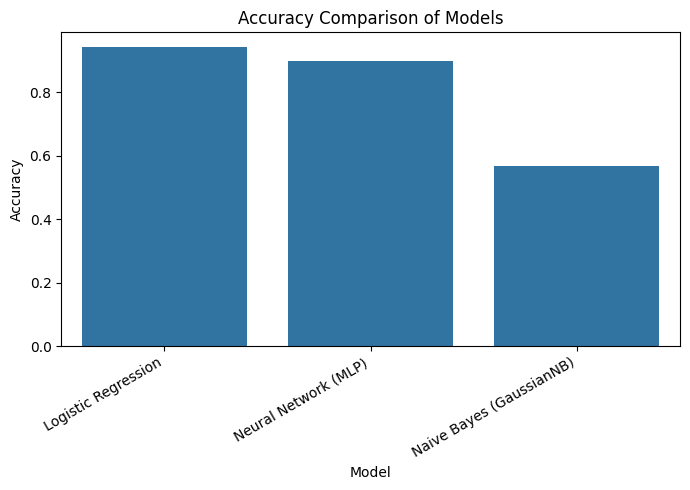

In [40]:
#Bar chart showcasing prediction accuracy of all models
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
sns.barplot( data=results_df,  x="Model", y="Accuracy")
plt.title("Accuracy Comparison of Models")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

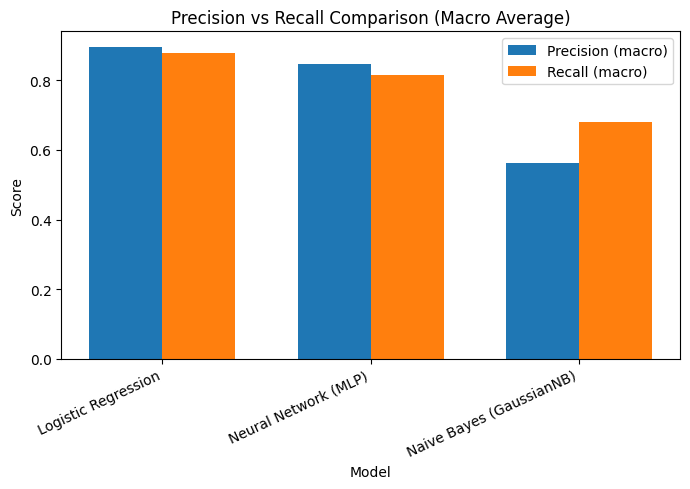

In [42]:
#Precision, recall comparison of each model
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(results_df))
width = 0.35

plt.figure(figsize=(7, 5))
plt.bar(x - width/2,results_df["Precision_macro"],width,label="Precision (macro)")
plt.bar(x + width/2, results_df["Recall_macro"],width, label="Recall (macro)")

plt.xticks(x, results_df["Model"], rotation=25, ha="right")
plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Precision vs Recall Comparison (Macro Average)")
plt.legend()
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


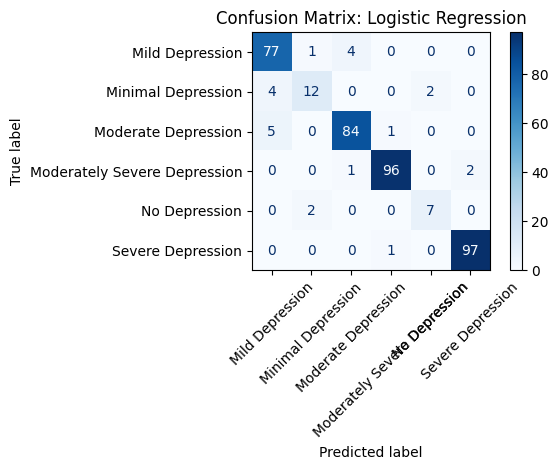

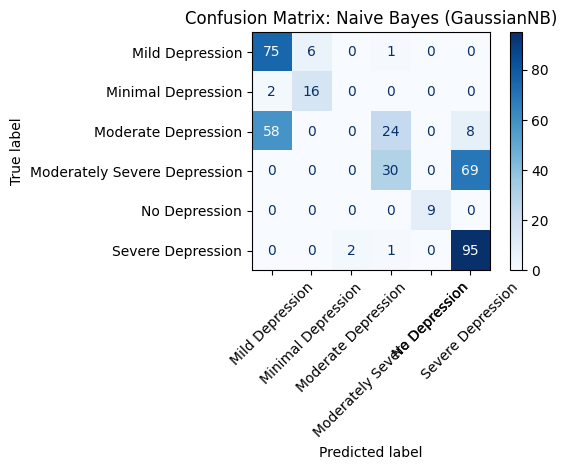

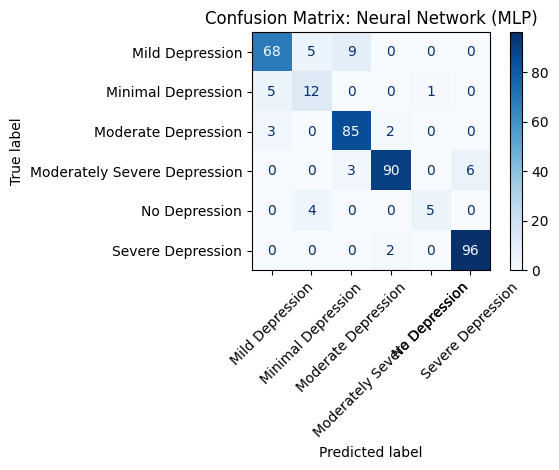

In [46]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

classes = sorted(y.unique())

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred, labels=classes)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=classes
    )
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title(f"Confusion Matrix: {name}")
    plt.tight_layout()
    plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


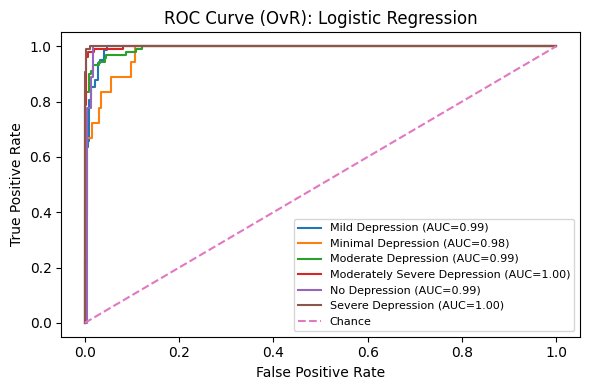

Logistic Regression Macro AUC: 0.9927


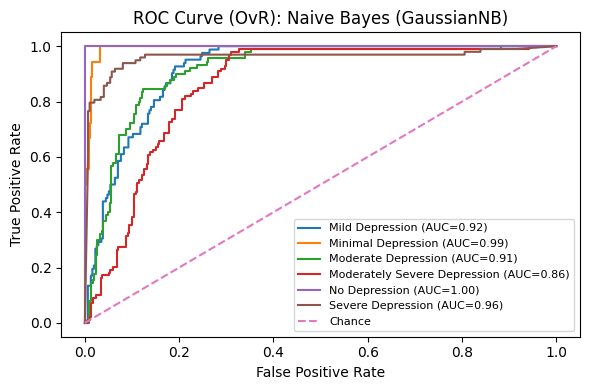

Naive Bayes (GaussianNB) Macro AUC: 0.9400


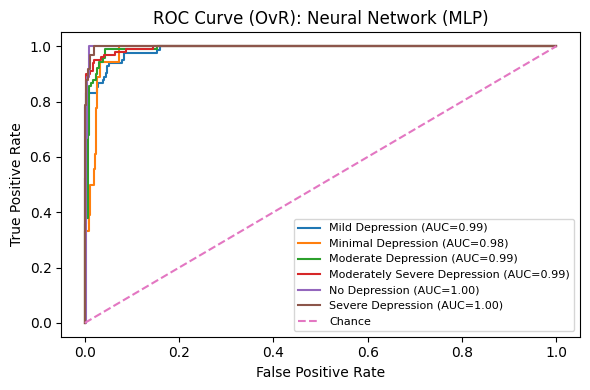

Neural Network (MLP) Macro AUC: 0.9919


In [47]:
#AUC score, ROC curve for each mode
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes = sorted(y.unique())
y_test_bin = label_binarize(y_test, classes=classes)

for name, model in models.items():
    # IMPORTANT: ensure model is trained before predict_proba
    model.fit(X_train, y_train)

    # class probability scores (shape: n_samples x n_classes)
    y_score = model.predict_proba(X_test)

    plt.figure(figsize=(6, 4))
    aucs = []

    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        plt.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")
    plt.title(f"ROC Curve (OvR): {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    print(f"{name} Macro AUC: {np.mean(aucs):.4f}")